In [10]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import cygno as cy
import pandas as pd
import midas.file_reader
from datetime import datetime
import time
from tqdm import tqdm
import os

In [12]:
mpath=f'/jupyter-workspace/cnaf-storage/cygno-data/NMV/WC/WC25/run00379.mid.gz'
if os.path.exists(mpath):
    mfile=midas.file_reader.MidasFile(mpath)
    odb=cy.get_bor_odb(mfile)
    corrected=odb.data["Configurations"]["DRS4Correction"]
    channels_offsets=odb.data["Configurations"]["DigitizerOffset"]
else:
    print("cazzo hai scritto?")

In [13]:
w0=[]
nevents=0
for event in mfile:
    if event.header.is_midas_internal_event():
        continue
    if "DGH0" in event.banks:
        nevents+=1
        full_header=cy.daq_dgz_full2header(event.banks["DGH0"], verbose=False)
        w_fast, w_slow = cy.daq_dgz_full2array(event.banks["DIG0"], full_header, verbose=False, corrected=corrected, ch_offset=channels_offsets)
        w0.append(w_fast[2])
print(len(w0))

4000


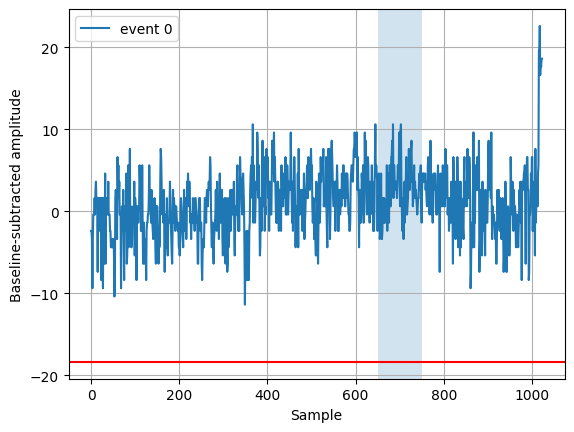

399


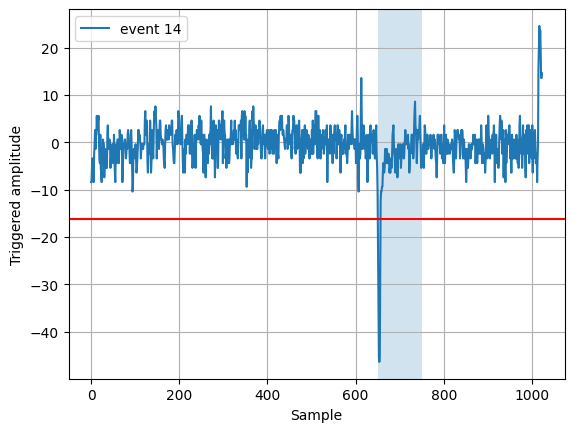

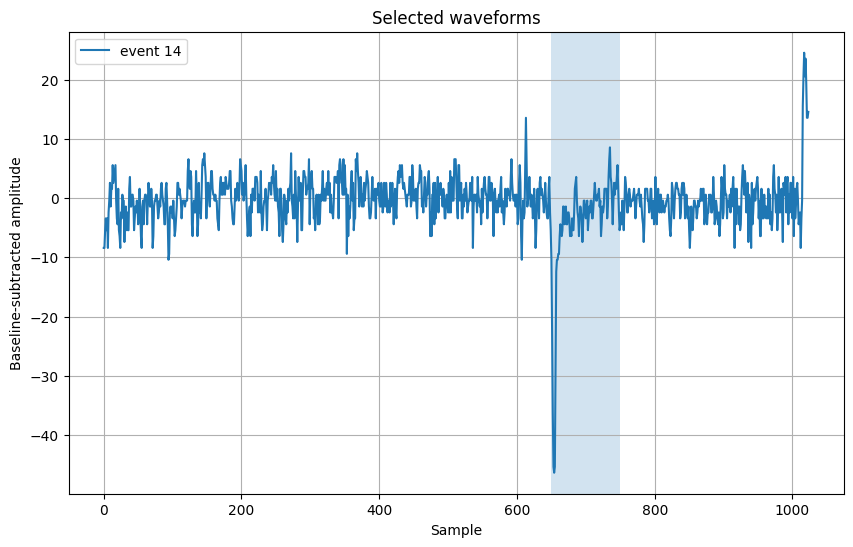

In [14]:
x_min, x_max = 650, 750
n_baseline = 500
max_plots = 1

sub_waveforms = []
rms_list = []
selected_waveforms = []
selected_indices = []
selected_rms = []

# baseline subtraction + per-waveform RMS
for wf in w0:
    wf = np.asarray(wf)
    baseline = np.mean(wf[:n_baseline])
    rms = np.std(wf[:n_baseline])

    wf_sub = wf - baseline
    sub_waveforms.append(wf_sub)
    rms_list.append(rms)

# plot first waveforms
for j in range(min(max_plots, len(sub_waveforms))):
    plt.figure()
    plt.plot(sub_waveforms[j], label=f"event {j}")
    plt.axvspan(x_min, x_max, alpha=0.2)
    plt.axhline(y=-5 * rms_list[j], color="red")
    plt.xlabel("Sample")
    plt.ylabel("Baseline-subtracted amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

# selection
for i, wf in enumerate(sub_waveforms):
    thr = -5 * rms_list[i]
    window = wf[x_min:x_max+1]
    if np.any(window < thr):
        selected_waveforms.append(wf)
        selected_indices.append(i)
        selected_rms.append(rms_list[i])
print(len(selected_waveforms))

# plot selected individually
for j in range(min(max_plots, len(selected_waveforms))):
    plt.figure()
    plt.plot(selected_waveforms[j], label=f"event {selected_indices[j]}")
    plt.axvspan(x_min, x_max, alpha=0.2)
    plt.axhline(y=-5 * selected_rms[j], color="red")
    plt.xlabel("Sample")
    plt.ylabel("Triggered amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

# overlay selected
plt.figure(figsize=(10, 6))
for j in range(min(max_plots, len(selected_waveforms))):
    plt.plot(selected_waveforms[j], label=f"event {selected_indices[j]}")

plt.axvspan(x_min, x_max, alpha=0.2)
plt.xlabel("Sample")
plt.ylabel("Baseline-subtracted amplitude")
plt.title("Selected waveforms")
plt.legend()
plt.grid(True)
plt.show()

Selected waveforms: 399
Dynamic signal mean charge = 0.7887 +/- 0.0302 pC
Matched noise mean charge  = -0.1393 +/- 0.0130 pC
Dynamic signal GAIN  = 4.93e+06


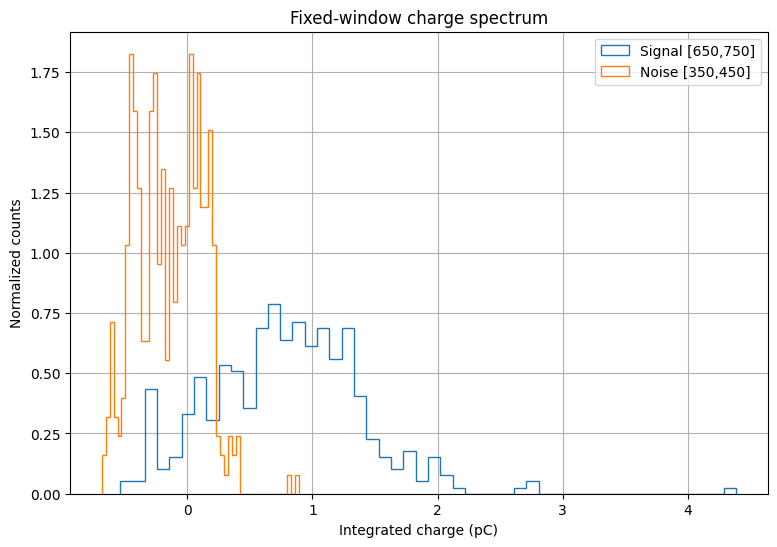

In [15]:
sig_min, sig_max = 650, 750
noise_min, noise_max = 450, 550
n_baseline = 500

dt_s = 0.4e-9           # 400 ps
adc_to_volt = 1.0/4096  # 1 V full scale, 4096 ADC channels
R_ohm = 50.0

charges_signal_pc = []
charges_noise_pc = []
selected_indices = []

for i, wf in enumerate(w0):
    wf = np.array(wf, dtype=float)

    if len(wf) <= max(sig_max, noise_max):
        continue

    baseline = np.mean(wf[:n_baseline])
    rms = np.std(wf[:n_baseline])
    wf_bs = wf - baseline

    # Select events with at least one significant negative excursion in [650,750]
    if np.any(wf_bs[sig_min:sig_max+1] < -5*rms):
        area_sig_adc = -np.sum(wf_bs[sig_min:sig_max+1])
        area_noise_adc = -np.sum(wf_bs[noise_min:noise_max+1])

        q_sig_pc = area_sig_adc * adc_to_volt * dt_s / R_ohm * 1e12
        q_noise_pc = area_noise_adc * adc_to_volt * dt_s / R_ohm * 1e12

        charges_signal_pc.append(q_sig_pc)
        charges_noise_pc.append(q_noise_pc)
        selected_indices.append(i)

charges_signal_pc = np.array(charges_signal_pc)
charges_noise_pc = np.array(charges_noise_pc)

print(f"Selected waveforms: {len(charges_signal_pc)}")
if len(charges_signal_pc) > 0:
    print(f"Dynamic signal mean charge = {np.mean(charges_signal_pc):.4f} +/- {np.std(charges_signal_pc)/np.sqrt(len(charges_signal_pc)):.4f} pC")
    print(f"Matched noise mean charge  = {np.mean(charges_noise_pc):.4f} +/- {np.std(charges_noise_pc)/np.sqrt(len(charges_signal_pc)):.4f} pC")
    print(f"Dynamic signal GAIN  = {np.mean(charges_signal_pc*1E-12/1.6E-19):.2e}")


plt.figure(figsize=(9,6))
plt.hist(charges_signal_pc, bins=50, histtype='step', density=True, label='Signal [650,750]')
plt.hist(charges_noise_pc, bins=50, histtype='step', density=True, label='Noise [350,450]')
plt.xlabel("Integrated charge (pC)")
plt.ylabel("Normalized counts")
plt.title("Fixed-window charge spectrum")
plt.legend()
plt.grid(True)
plt.show()

Selected waveforms: 399
Dynamic signal mean charge = 0.9255 +/- 0.0240 pC
Matched noise mean charge  = -0.0213 +/- 0.0025 pC
Mean duration             = 6.474 +/- 0.092 ns
Dynamic signal GAIN       = 5.78e+06


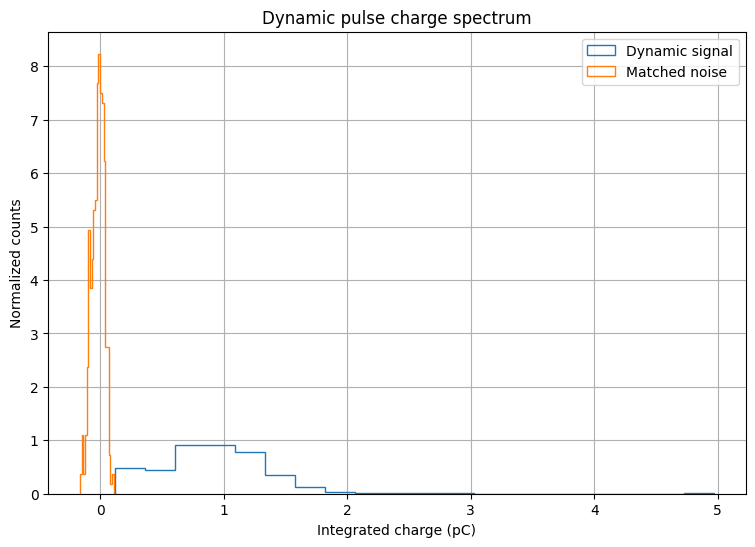

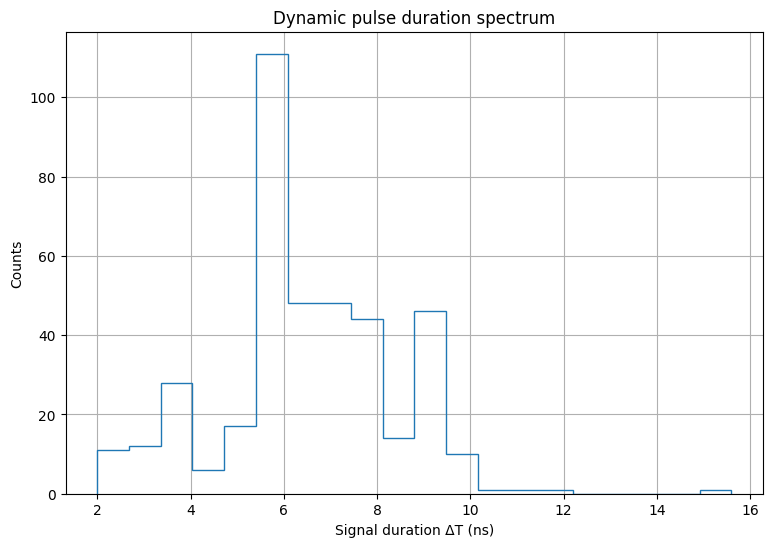

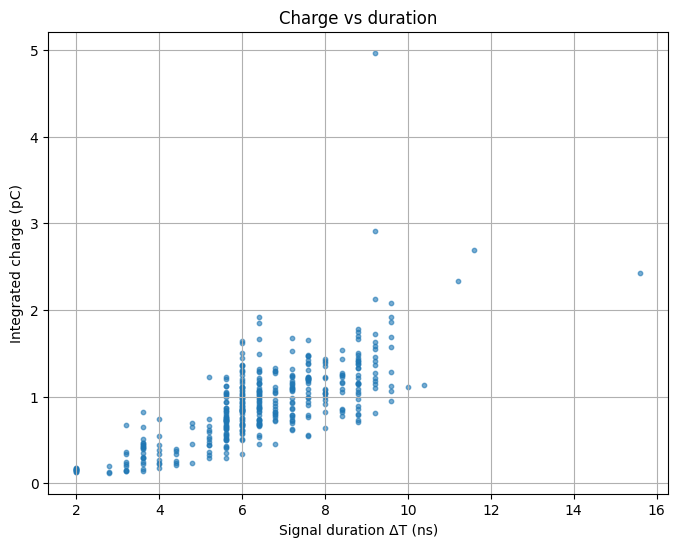

In [16]:
import numpy as np
import matplotlib.pyplot as plt

search_min, search_max = 650, 750
noise_ref_min, noise_ref_max = 450, 550
n_baseline = 500

dt_s = 0.4e-9
dt_ns = 0.4
adc_to_volt = 1.0 / 4096
R_ohm = 50.0
e_charge = 1.6e-19

charges_signal_dyn_pc = []
charges_noise_dyn_pc = []
durations_ns = []
durations_samples = []
selected_indices_dyn = []
pulse_info = []

for i, wf in enumerate(w0):
    wf = np.array(wf, dtype=float)

    if len(wf) <= max(search_max, noise_ref_max):
        continue

    baseline = np.mean(wf[:n_baseline])
    rms = np.std(wf[:n_baseline])
    wf_bs = wf - baseline

    search_region = wf_bs[search_min:search_max+1]

    # Trigger condition
    if not np.any(search_region < -5 * rms):
        continue

    # Minimum position inside search window
    imin_local = np.argmin(search_region)
    imin = search_min + imin_local

    # Dynamic boundaries: expand until waveform goes back above -1*rms
    left = imin
    while left > 0 and wf_bs[left] < -1.0 * rms:
        left -= 1

    right = imin
    while right < len(wf_bs) - 1 and wf_bs[right] < -1.0 * rms:
        right += 1

    # Pulse duration
    width = right - left + 1
    delta_t_ns = width * dt_ns

    # Pulse area
    area_sig_adc = -np.sum(wf_bs[left:right+1])
    q_sig_pc = area_sig_adc * adc_to_volt * dt_s / R_ohm * 1e12

    # Matched noise window with same width inside [450,550]
    noise_center = (noise_ref_min + noise_ref_max) // 2
    noise_left = noise_center - width // 2
    noise_right = noise_left + width - 1

    if noise_left < noise_ref_min:
        noise_left = noise_ref_min
        noise_right = noise_left + width - 1
    if noise_right > noise_ref_max:
        noise_right = noise_ref_max
        noise_left = noise_right - width + 1

    if noise_left < noise_ref_min or noise_right > noise_ref_max:
        continue

    area_noise_adc = -np.sum(wf_bs[noise_left:noise_right+1])
    q_noise_pc = area_noise_adc * adc_to_volt * dt_s / R_ohm * 1e12

    charges_signal_dyn_pc.append(q_sig_pc)
    charges_noise_dyn_pc.append(q_noise_pc)
    durations_ns.append(delta_t_ns)
    durations_samples.append(width)
    selected_indices_dyn.append(i)
    pulse_info.append((left, right, imin, noise_left, noise_right, rms, delta_t_ns))

charges_signal_dyn_pc = np.array(charges_signal_dyn_pc)
charges_noise_dyn_pc = np.array(charges_noise_dyn_pc)
durations_ns = np.array(durations_ns)
durations_samples = np.array(durations_samples)

print(f"Selected waveforms: {len(charges_signal_dyn_pc)}")
if len(charges_signal_dyn_pc) > 0:
    print(f"Dynamic signal mean charge = {np.mean(charges_signal_dyn_pc):.4f} +/- {np.std(charges_signal_dyn_pc)/np.sqrt(len(charges_signal_dyn_pc)):.4f} pC")
    print(f"Matched noise mean charge  = {np.mean(charges_noise_dyn_pc):.4f} +/- {np.std(charges_noise_dyn_pc)/np.sqrt(len(charges_noise_dyn_pc)):.4f} pC")
    print(f"Mean duration             = {np.mean(durations_ns):.3f} +/- {np.std(durations_ns)/np.sqrt(len(durations_ns)):.3f} ns")
    print(f"Dynamic signal GAIN       = {(np.mean(charges_signal_dyn_pc) * 1e-12 / e_charge):.2e}")

plt.figure(figsize=(9,6))
plt.hist(charges_signal_dyn_pc, bins=20, histtype='step', density=True, label='Dynamic signal')
plt.hist(charges_noise_dyn_pc, bins=20, histtype='step', density=True, label='Matched noise')
plt.xlabel("Integrated charge (pC)")
plt.ylabel("Normalized counts")
plt.title("Dynamic pulse charge spectrum")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9,6))
plt.hist(durations_ns, bins=20, histtype='step')
plt.xlabel("Signal duration ΔT (ns)")
plt.ylabel("Counts")
plt.title("Dynamic pulse duration spectrum")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(durations_ns, charges_signal_dyn_pc, s=10, alpha=0.6)
plt.xlabel("Signal duration ΔT (ns)")
plt.ylabel("Integrated charge (pC)")
plt.title("Charge vs duration")
plt.grid(True)
plt.show()